<a href="https://colab.research.google.com/github/sonia-rafique/Data-Science-Artifacts/blob/main/Task%202/Mall_Customer_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Initial Corporate Dataset Preview ---
   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  

--- Missing Values and Architectural Types Audit ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender  

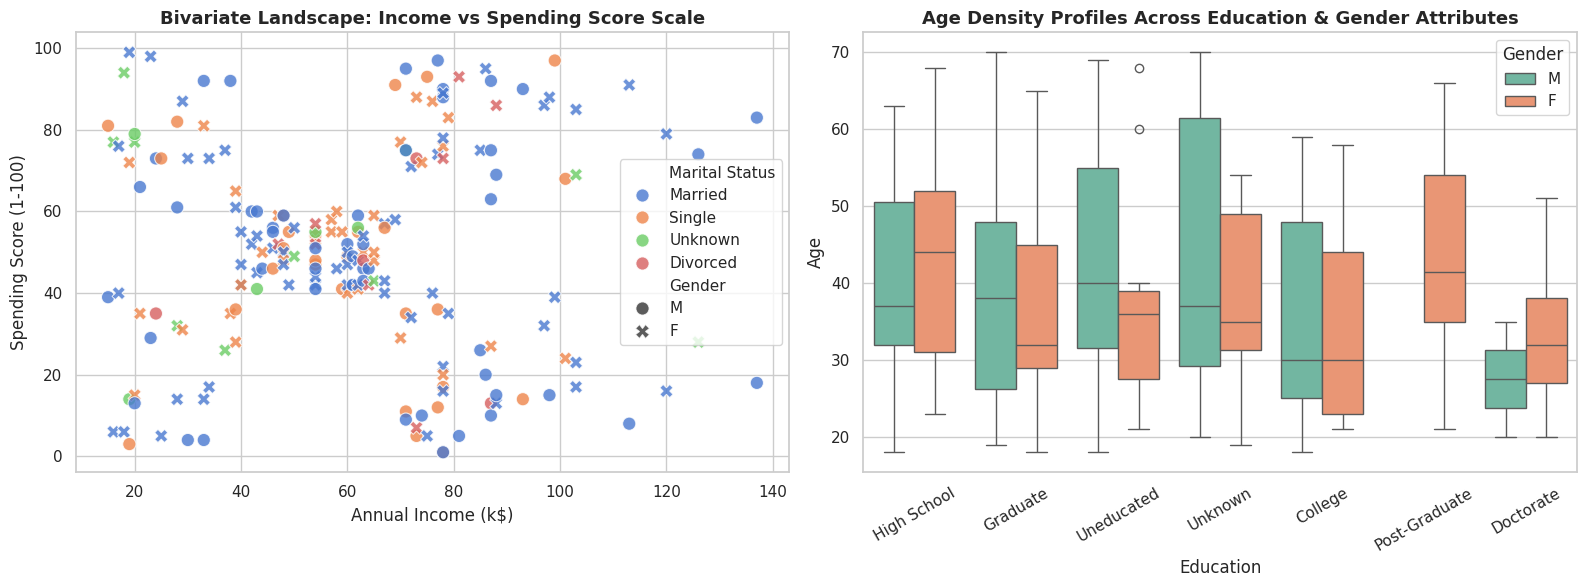

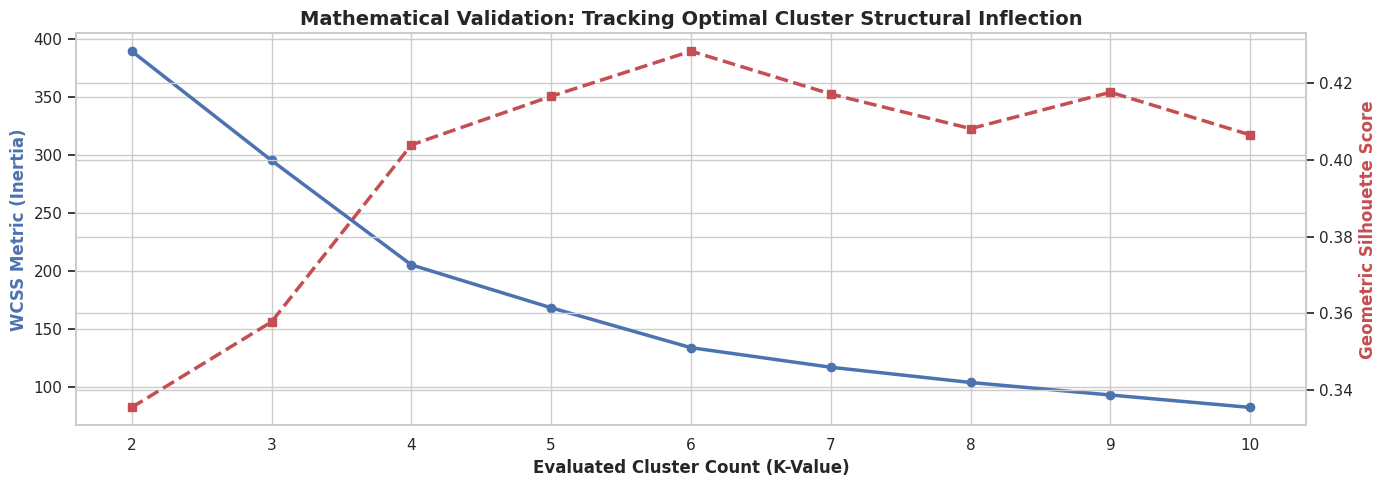

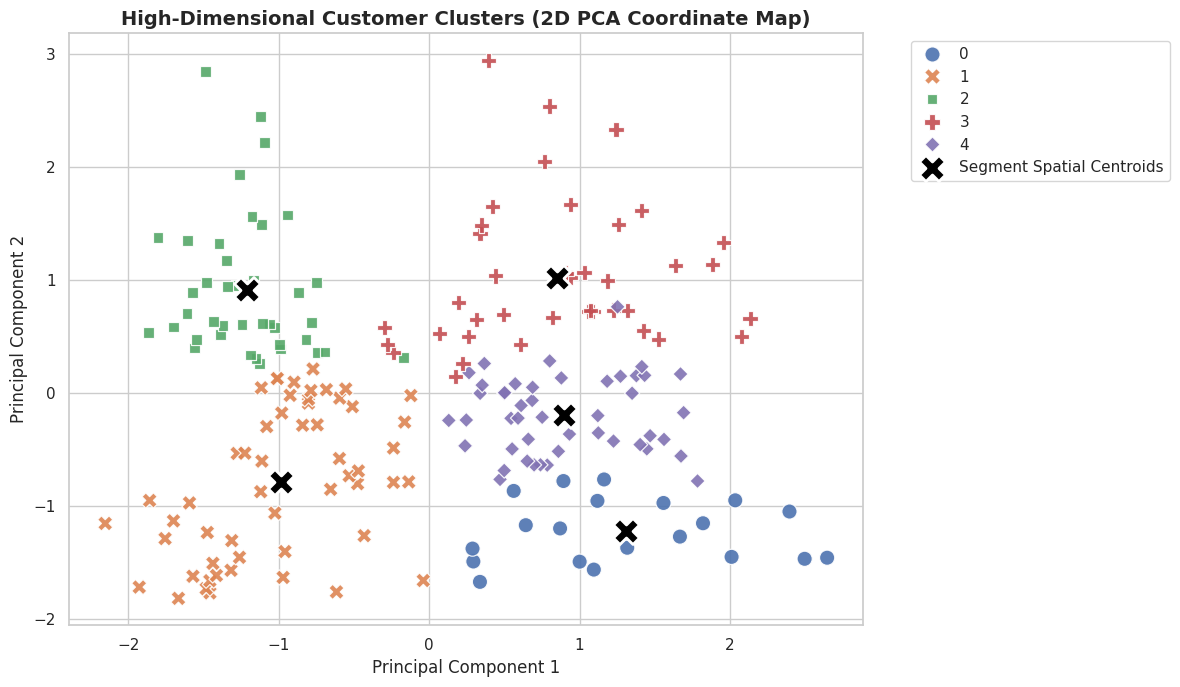


             ENTERPRISE GRADE SEGMENT INFRASTRUCTURE MANAGEMENT REPORT


,Age,Annual Income (k$),Spending Score (1-100),Total Cohort Volume
Cluster,,,,
0,46.250000,26.750000,18.350000,20
1,25.190000,41.090000,62.240000,54
2,32.880000,86.100000,81.530000,40
3,39.870000,86.100000,19.360000,39
4,55.640000,54.380000,48.850000,47



-------------------------------------------------------------------------------------
                     AUTOMATED TARGETED PLAYBOOK DEPLOYMENT DETAILS
-------------------------------------------------------------------------------------

[CLUSTER #0] Profile Identity: Budget Frugals (Older, Low Earnings, Low Spending Profile)
 -> Marketing Action Directive: Target with essential value bundles, clearance sales alerts, and plain discount coupons.

[CLUSTER #1] Profile Identity: Resourceful Trendsetters (Younger, Mid Earnings, High Spending Profile)
 -> Marketing Action Directive: Engage via digital social campaigns, subscription flash sales, and buy-now-pay-later (BNPL) options.

[CLUSTER #2] Profile Identity: Premium High-Rollers (Mid-Age, High Earnings, High Spending Profile)
 -> Marketing Action Directive: Enroll in elite concierge tiers, VIP product previews, and assign premium account managers.

[CLUSTER #3] Profile Identity: Conservative Affluents (Mid-Age, High Earnings, Low S

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Set overall graph style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# =========================
# 1. LOAD & CLEAN DATA
# =========================

# Load dataset
df = pd.read_excel('Mall Customers.xlsx')

# Preview dataset
print("--- Initial Corporate Dataset Preview ---")
print(df.head())

# Check data types and missing values
print("\n--- Missing Values and Architectural Types Audit ---")
print(df.info())

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert important columns into numeric values
df['Annual Income (k$)'] = pd.to_numeric(df['Annual Income (k$)'], errors='coerce')
df['Spending Score (1-100)'] = pd.to_numeric(df['Spending Score (1-100)'], errors='coerce')

# Remove rows with missing important values
df.dropna(subset=['Annual Income (k$)', 'Spending Score (1-100)'], inplace=True)


# =========================
# 2. DATA VISUALIZATION
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Income vs spending behavior
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Marital Status', style='Gender', s=90, alpha=0.8, ax=axes[0]
)

axes[0].set_title('Bivariate Landscape: Income vs Spending Score Scale', fontsize=13, weight='bold')

# Age distribution by education and gender
sns.boxplot(
    data=df, x='Education', y='Age', hue='Gender',
    ax=axes[1], palette='Set2'
)

axes[1].set_title('Age Density Profiles Across Education & Gender Attributes', fontsize=13, weight='bold')

plt.setp(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('eda_demographics_dashboard.png', dpi=300)
plt.show()


# =========================
# 3. FEATURE SCALING & FINDING BEST K
# =========================

# Select features for clustering
segmentation_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[segmentation_features]

# Normalize data for fair clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
silhouette_avg_scores = []
cluster_range = range(2, 11)

# Try different K values
for k in cluster_range:

    kmeans_engine = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    labels = kmeans_engine.fit_predict(X_scaled)

    # Store WCSS and silhouette scores
    wcss.append(kmeans_engine.inertia_)
    silhouette_avg_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow + Silhouette graphs
fig, ax1 = plt.subplots(figsize=(14, 5))

color_wcss = '#4C72B0'

ax1.set_xlabel('Evaluated Cluster Count (K-Value)', weight='bold')
ax1.set_ylabel('WCSS Metric (Inertia)', color=color_wcss, weight='bold')

ax1.plot(
    cluster_range,
    wcss,
    marker='o',
    color=color_wcss,
    linewidth=2.5
)

ax1.set_title(
    'Mathematical Validation: Tracking Optimal Cluster Structural Inflection',
    fontsize=14,
    weight='bold'
)

# Second graph for silhouette score
ax2 = ax1.twinx()

color_sil = '#C44E52'

ax2.set_ylabel('Geometric Silhouette Score', color=color_sil, weight='bold')

ax2.plot(
    cluster_range,
    silhouette_avg_scores,
    marker='s',
    color=color_sil,
    linewidth=2.5,
    linestyle='--'
)

plt.tight_layout()
plt.savefig('cluster_optimization_diagnostics.png', dpi=300)
plt.show()


# =========================
# 4. TRAIN K-MEANS MODEL
# =========================

# Final clustering with K=5
optimal_k = 5

production_kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    random_state=42,
    n_init=10
)

# Assign cluster labels
df['Cluster'] = production_kmeans.fit_predict(X_scaled)

# Reduce dimensions for visualization
pca_engine = PCA(n_components=2, random_state=42)
X_pca = pca_engine.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot customer clusters
plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='deep',
    s=120,
    alpha=0.9,
    style='Cluster',
    markers=True
)

# Plot cluster centers
transformed_centroids = pca_engine.transform(
    production_kmeans.cluster_centers_
)

plt.scatter(
    transformed_centroids[:, 0],
    transformed_centroids[:, 1],
    s=350,
    c='black',
    marker='X',
    edgecolors='white',
    linewidths=2,
    label='Segment Spatial Centroids'
)

plt.title(
    'High-Dimensional Customer Clusters (2D PCA Coordinate Map)',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('customer_segmentation_pca_space.png', dpi=300)
plt.show()


# =========================
# 5. CUSTOMER PERSONAS & MARKETING STRATEGY
# =========================

# Cluster names
persona_directory = {
    0: "Budget Frugals (Older, Low Earnings, Low Spending Profile)",
    1: "Resourceful Trendsetters (Younger, Mid Earnings, High Spending Profile)",
    2: "Premium High-Rollers (Mid-Age, High Earnings, High Spending Profile)",
    3: "Conservative Affluents (Mid-Age, High Earnings, Low Spending Profile)",
    4: "Stable Traditionalists (Mature, Mid Earnings, Mid Spending Profile)"
}

# Marketing actions
strategy_directory = {
    0: "Target with essential value bundles, clearance sales alerts, and plain discount coupons.",
    1: "Engage via digital social campaigns, subscription flash sales, and buy-now-pay-later (BNPL) options.",
    2: "Enroll in elite concierge tiers, VIP product previews, and assign premium account managers.",
    3: "Promote cashback credit cards, multi-device ecosystem warranties, and wealth asset protections.",
    4: "Support with stable milestone loyalty point trackers, direct mailers, and customer service guarantees."
}

# Map personas and strategies to clusters
df['Customer_Persona'] = df['Cluster'].map(persona_directory)
df['Marketing_Playbook'] = df['Cluster'].map(strategy_directory)

print("\n" + "="*85)
print("             ENTERPRISE GRADE SEGMENT INFRASTRUCTURE MANAGEMENT REPORT")
print("="*85)

# Average values of each cluster
profile_summary = df.groupby('Cluster')[segmentation_features].mean()

# Add total customers in each cluster
profile_summary['Total Cohort Volume'] = df['Cluster'].value_counts().sort_index()

# Create styled summary table
styled_matrix = profile_summary.round(2).style.background_gradient(
    cmap='Blues',
    subset=segmentation_features
).set_properties(**{
    'font-weight': '600',
    'text-align': 'center',
    'border-color': '#cccccc'
}).set_caption("EXECUTIVE REPORT: EMPIRICAL CLUSTER COHORT MEANS MATRIX")

# Display summary table
display(styled_matrix)

print("\n" + "-"*85)
print("                     AUTOMATED TARGETED PLAYBOOK DEPLOYMENT DETAILS")
print("-"*85)

# Print cluster details
for cluster_id in sorted(persona_directory.keys()):

    print(f"\n[CLUSTER #{cluster_id}] Profile Identity: {persona_directory[cluster_id]}")
    print(f" -> Marketing Action Directive: {strategy_directory[cluster_id]}")

# Export each cluster into separate CSV files
for cluster_id, cohort_name in [
    (0, 'budget_frugals'),
    (1, 'resourceful_trendsetters'),
    (2, 'premium_high_rollers'),
    (3, 'conservative_affluents'),
    (4, 'stable_traditionalists')
]:

    cohort_slice = df[df['Cluster'] == cluster_id].drop(columns=['PCA1', 'PCA2'])

    cohort_slice.to_csv(
        f"segment_cohort_{cohort_name}.csv",
        index=False
    )

print("\n" + "="*85)
print("SUCCESS: Distinct CRM customer segments successfully exported as isolated system data tables.")
print("="*85)